In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense,Dropout
import json
import glob

# Load all JSON files
json_files = glob.glob('*.json')
all_samples = []

for file in json_files:
    with open(file, "r") as f:
        raw = json.load(f)
    
    if isinstance(raw, list):
        for session in raw:
            samples = session['samples']
            all_samples.extend(samples)
    else:
        samples = raw['samples']
        all_samples.extend(samples)

print(f"Total samples: {len(all_samples)}")
# Extract samples
df_data = pd.DataFrame(all_samples)
df = pd.json_normalize(all_samples)

print(df_data.columns.tolist())
df_data.set_index('time', inplace=True)
print(df_data.head())

Total samples: 13461
['time', 'env', 'trial', 'user', 'pois']
       env  trial                                               user  \
time                                                                   
9303.7   D      1  {'x': -0.009576471146144114, 'z': -0.020370276...   
9354.3   D      1  {'x': -0.008997241417596447, 'z': -0.020436469...   
9403.6   D      1  {'x': -0.00861159972056974, 'z': -0.0201739579...   
9455.3   D      1  {'x': -0.008545451095556864, 'z': -0.020026871...   
9503.7   D      1  {'x': -0.008380717327506847, 'z': -0.019520434...   

                                                     pois  
time                                                       
9303.7  [{'distance': 1.253272932899953, 'angle': 1.21...  
9354.3  [{'distance': 1.253799755449084, 'angle': 1.21...  
9403.6  [{'distance': 1.2542495012332384, 'angle': 1.2...  
9455.3  [{'distance': 1.2543596089658189, 'angle': 1.2...  
9503.7  [{'distance': 1.2546791690551167, 'angle': 1.2...  


In [102]:
# Filter valid samples
df_data = df_data[df_data['user'].apply(lambda x: isinstance(x, dict)) & df_data['pois'].apply(lambda x: isinstance(x, list))]
print(f"Filtered data length: {len(df_data)}")

Filtered data length: 13461


In [103]:
print(df_data['user'].apply(type).value_counts())
print(df_data['pois'].apply(type).value_counts())

user
<class 'dict'>    13461
Name: count, dtype: int64
pois
<class 'list'>    13461
Name: count, dtype: int64


In [104]:
print(df_data.columns)

Index(['env', 'trial', 'user', 'pois'], dtype='str')


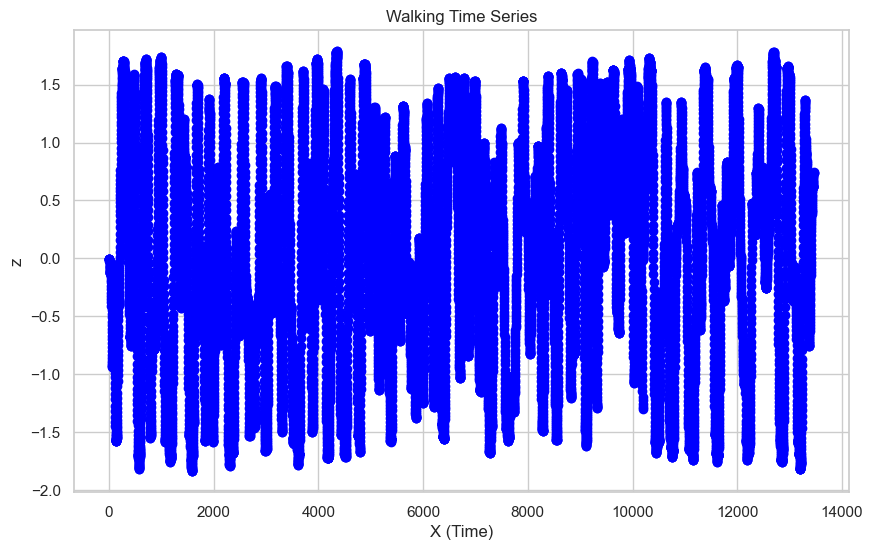

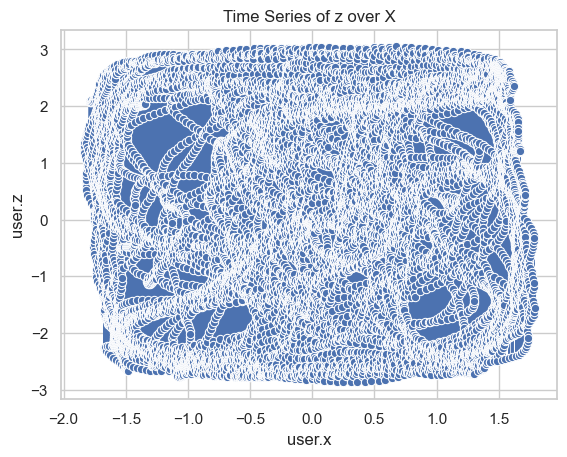

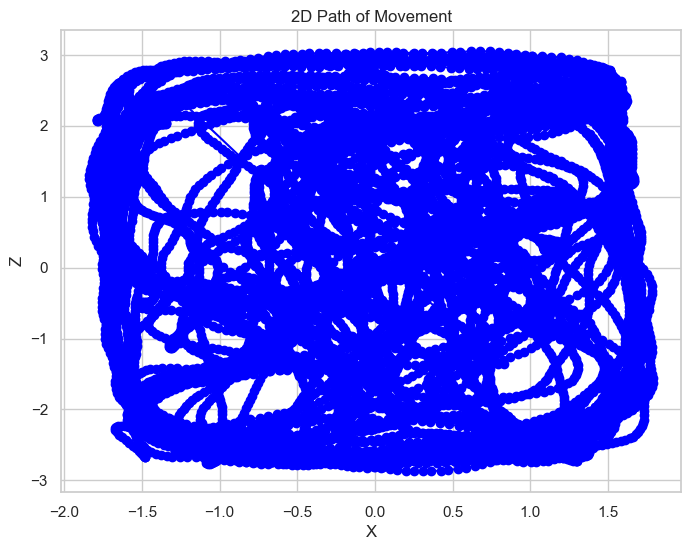

In [105]:
plt.figure(figsize=(10, 6))
plt.plot(df['user.x'], marker='o', linestyle='-',color='blue')
plt.title('Walking Time Series')
plt.xlabel('X (Time)')
plt.ylabel('z')
plt.grid(True)
plt.show()

sns.set(style="whitegrid")
sns.lineplot(x='user.x', y='user.z', data=df, marker='o')
plt.title('Time Series of z over X')
plt.show()

fig = px.line(df, x='user.x', y='user.z', title='Interactive Time Series of z over X')

fig.update_layout(
    xaxis_title='X (Time)',
    yaxis_title='z',
    template='plotly_white'
)

fig.show()

# Plot path
plt.figure(figsize=(8, 6))
plt.plot(df['user.x'], df['user.z'], marker='o', linestyle='-', color='blue')
plt.title('2D Path of Movement')
plt.xlabel('X')
plt.ylabel('Z')
plt.grid(True)
plt.show()

plt.show()

In [106]:
# Flatten user
print(f"df_data len: {len(df_data)}")
user_df = pd.json_normalize(df_data['user'])
user_df.columns = ['x', 'z', 'vx', 'vz', 'yaw']
print(f"user_df len: {len(user_df)}")
# user_df['env'] = data['env']
# user_df['trial'] = data['trial']
# user_df['time'] = data['time']

df_data len: 13461
user_df len: 13461


In [107]:
# Flatten POIs with relative angles
# Extract yaw for relative angles
yaw_series = df_data['user'].apply(lambda x: x['yaw'])

def flatten_pois_safe(row, yaw, max_pois=5):
    pois_list = row
    
    # Handle bad rows
    if not isinstance(pois_list, list):
        return {f'poi_{i}_{k}': 0 for i in range(max_pois) for k in ['dist', 'angle']}
    
    # Sort by distance
    pois_list = sorted(pois_list, key=lambda x: x['distance'])
    
    flat = {}
    
    for i in range(max_pois):
        if i < len(pois_list):
            flat[f'poi_{i}_dist'] = pois_list[i]['distance']
            # Compute relative angle and wrap to [-pi, pi]
            rel_angle = pois_list[i]['angle'] - yaw
            flat[f'poi_{i}_angle'] = np.arctan2(np.sin(rel_angle), np.cos(rel_angle))
        else:
            flat[f'poi_{i}_dist'] = 0
            flat[f'poi_{i}_angle'] = 0
    
    return flat

pois_df = pd.DataFrame([flatten_pois_safe(p, y) for p, y in zip(df_data['pois'], yaw_series)])


In [108]:
# Flatten user
user_df = pd.json_normalize(df_data['user'])
user_df.columns = ['x', 'z', 'vx', 'vz', 'yaw']

In [109]:
print(type(df_data['pois'].iloc[0]))
print(df_data['pois'].iloc[0])

<class 'list'>
[{'distance': 1.253272932899953, 'angle': 1.2139552903169568}, {'distance': 1.9673928533215423, 'angle': 0.7034945170166381}, {'distance': 2.309717385714271, 'angle': 0.848629759227636}, {'distance': 2.525997930279281, 'angle': 0.5762463016909609}, {'distance': 2.9614143598956626, 'angle': 0.07653475677376848}]


In [110]:
print(pois_df.head())

   poi_0_dist  poi_0_angle  poi_1_dist  poi_1_angle  poi_2_dist  poi_2_angle  \
0    1.253273     1.185671    1.967393     0.675210    2.309717     0.820345   
1    1.253800     1.184771    1.967730     0.674457    2.310120     0.819494   
2    1.254250     1.183313    1.968183     0.673199    2.310584     0.818182   
3    1.254360     1.182320    1.968337     0.672288    2.310729     0.817261   
4    1.254679     1.174390    1.968824     0.664665    2.311180     0.809596   

   poi_3_dist  poi_3_angle  poi_4_dist  poi_4_angle  
0    2.525998     0.547962    2.961414     0.048250  
1    2.526272     0.547218    2.961401     0.049045  
2    2.526707     0.545990    2.961698     0.048590  
3    2.526866     0.545098    2.961850     0.047982  
4    2.527376     0.537561    2.962370     0.042400  


In [111]:
# Combine (use index as time)
df_final = pd.concat([
    df_data.reset_index()[['time', 'env', 'trial']].reset_index(drop=True),
    user_df.reset_index(drop=True),
    pois_df.reset_index(drop=True)
], axis=1)

df_final = df_final.dropna()

print(f"Lengths: df_data {len(df_data)}, user_df {len(user_df)}, pois_df {len(pois_df)}, df_final {len(df_final)}")
print(df_final['env'].value_counts())
print(df.head())

Lengths: df_data 13461, user_df 13461, pois_df 13461, df_final 13461
env
D    4990
C    3265
B    2833
A    2373
Name: count, dtype: int64
     time env  trial                                               pois  \
0  9303.7   D      1  [{'distance': 1.253272932899953, 'angle': 1.21...   
1  9354.3   D      1  [{'distance': 1.253799755449084, 'angle': 1.21...   
2  9403.6   D      1  [{'distance': 1.2542495012332384, 'angle': 1.2...   
3  9455.3   D      1  [{'distance': 1.2543596089658189, 'angle': 1.2...   
4  9503.7   D      1  [{'distance': 1.2546791690551167, 'angle': 1.2...   

     user.x    user.z   user.vx   user.vz  user.yaw  
0 -0.009576 -0.020370  0.014867 -0.005156  0.028285  
1 -0.008997 -0.020436  0.011447 -0.001308  0.028859  
2 -0.008612 -0.020174  0.007822  0.005325  0.029549  
3 -0.008545 -0.020027  0.001279  0.002845  0.030001  
4 -0.008381 -0.019520  0.003404  0.010464  0.033816  


In [112]:
# Splitting by environment
test_env = 'A'

train_df = df_final[df_final['env'] != test_env]
test_df  = df_final[df_final['env'] == test_env]

In [113]:
print(df_final['env'].value_counts())

env
D    4990
C    3265
B    2833
A    2373
Name: count, dtype: int64


In [114]:
# # Scaling the data for LSTM
# scaler = MinMaxScaler()
# scaled_data = scaler.fit_transform(df)

In [115]:
# Create sequences for LSTM
def create_sequences_grouped(df, seq_length=10):
    X, y = [], []
    
    for _, group in df.groupby(['env', 'trial']):
        
        group = group.reset_index(drop=True)
        
        # Drop non-feature columns
        features = group.drop(columns=['env', 'trial', 'time']).values
        
        for i in range(len(features) - seq_length):
            X.append(features[i:i+seq_length])
            y.append(features[i+seq_length][:2])  # predict x, z
    
    return np.array(X), np.array(y)

In [116]:
# Create sequences
SEQ_LENGTH = 50
X_train, y_train = create_sequences_grouped(train_df, seq_length=SEQ_LENGTH)
X_test, y_test = create_sequences_grouped(test_df, seq_length=SEQ_LENGTH)
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (8838, 50, 15), y_train shape: (8838, 2)
X_test shape: (1623, 50, 15), y_test shape: (1623, 2)


In [117]:
# Build LSTM model
model = Sequential([
    LSTM(64, input_shape=(SEQ_LENGTH, 15),return_sequences=True),
    LSTM(64, input_shape=(SEQ_LENGTH, 15)),
    Dropout(0.3),
    # Dense(32, activation='relu'),
    Dense(2)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

c:\Users\JetPa\anaconda3\envs\mnist_tf2\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_11 (LSTM)                  │ (None, 50, 64)         │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,634 (209.51 KB)

 Trainable params: 53,634 (209.51 KB)

 Non-trainable params: 0 (0.00 B)

In [118]:
# Train the model
model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.1564 - val_loss: 0.0182
Epoch 2/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0406 - val_loss: 0.0122
Epoch 3/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0371 - val_loss: 0.0093
Epoch 4/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0352 - val_loss: 0.0090
Epoch 5/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0338 - val_loss: 0.0134
Epoch 6/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0331 - val_loss: 0.0077
Epoch 7/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0321 - val_loss: 0.0056
Epoch 8/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0309 - val_loss: 0.0088
Epoch 9/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0314 - val_loss: 0.0052
Epoch 10/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0312 - val_loss: 0.0074
Epoch 11/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0309 - val_loss: 0.0050
Epoch 12/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 

In [119]:
# make predictions
preds = model.predict(X_test)

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


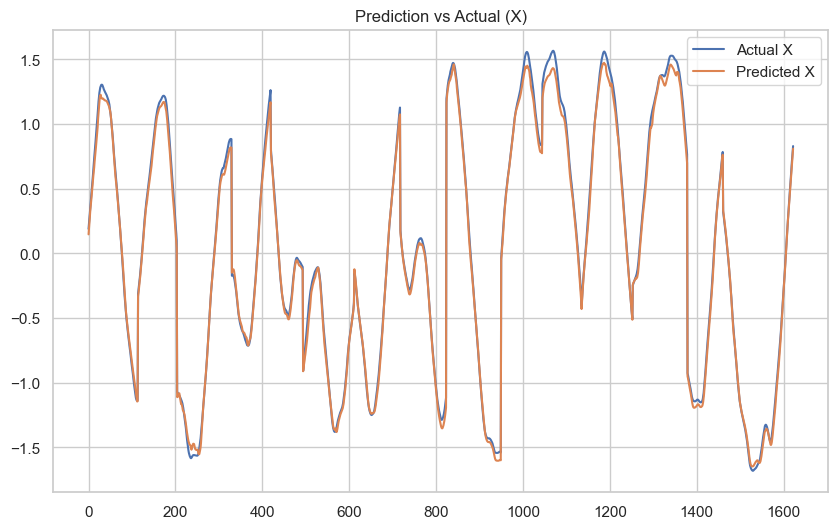

In [120]:
# Plot actual vs predicted for X
plt.figure(figsize=(10,6))

# Actual
plt.plot(y_test[:,0], label='Actual X')
# Predicted
plt.plot(preds[:,0], label='Predicted X')

plt.legend()
plt.title("Prediction vs Actual (X)")
plt.show()

In [121]:
# Select one trial from environment D
selected_trial = test_df['trial'].unique()[0]
test_df_single = test_df[test_df['trial'] == selected_trial]

# Create sequences for this single trial
X_test_single, y_test_single = create_sequences_grouped(test_df_single, seq_length=SEQ_LENGTH)
preds_single = model.predict(X_test_single)

# Get actual positions
actual_x = test_df_single['x'].values
actual_z = test_df_single['z'].values

# Current positions
current_x = X_test_single[:, -1, 0]
current_z = X_test_single[:, -1, 1]

# Predicted next
pred_x = preds_single[:, 0]
pred_z = preds_single[:, 1]

# Calculate POI positions (at the user's position when closest to each POI)
poi_x_list = []
poi_z_list = []
for poi in range(5):
    dist_col = f'poi_{poi}_dist'
    min_dist_idx = test_df_single[dist_col].idxmin()
    poi_x = test_df_single.loc[min_dist_idx, 'x']
    poi_z = test_df_single.loc[min_dist_idx, 'z']
    poi_x_list.append(poi_x)
    poi_z_list.append(poi_z)

# Plot interactive map
import plotly.graph_objects as go

fig = go.Figure()

# Add actual path
fig.add_trace(go.Scatter(x=actual_x, y=actual_z, mode='lines+markers', name='Actual Path', 
                         line=dict(color='blue', width=2), marker=dict(size=4)))

# Add start and end markers
fig.add_trace(go.Scatter(x=[actual_x[0]], y=[actual_z[0]], mode='markers', name='Start', 
                         marker=dict(color='green', size=10, symbol='star')))
fig.add_trace(go.Scatter(x=[actual_x[-1]], y=[actual_z[-1]], mode='markers', name='End', 
                         marker=dict(color='purple', size=10, symbol='star')))

# Add predicted steps
for i in range(len(current_x)):
    fig.add_trace(go.Scatter(x=[current_x[i], pred_x[i]], y=[current_z[i], pred_z[i]], 
                             mode='lines', name='Predicted Step' if i == 0 else '', 
                             line=dict(color='red', width=2, dash='dash'), showlegend=i==0))

# Add POIs
fig.add_trace(go.Scatter(x=poi_x_list, y=poi_z_list, mode='markers', name='POIs', 
                         marker=dict(color='green', size=6, symbol='x')))

fig.update_layout(
    title=f'Map of Actual and Predicted User Walking Paths (Environment D, Trial {selected_trial})',
    xaxis_title='X Position',
    yaxis_title='Z Position',
    width=800,
    height=600
)

fig.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [122]:
# Evaluate model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_x = mean_absolute_error(y_test[:, 0], preds[:, 0])
mae_z = mean_absolute_error(y_test[:, 1], preds[:, 1])
rmse_x = np.sqrt(mean_squared_error(y_test[:, 0], preds[:, 0]))
rmse_z = np.sqrt(mean_squared_error(y_test[:, 1], preds[:, 1]))

print(f"Test MAE - X: {mae_x:.4f}, Z: {mae_z:.4f}")
print(f"Test RMSE - X: {rmse_x:.4f}, Z: {rmse_z:.4f}")

# Overall MAE and RMSE
mae_overall = (mae_x + mae_z) / 2
rmse_overall = (rmse_x + rmse_z) / 2
print(f"Overall MAE: {mae_overall:.4f}, RMSE: {rmse_overall:.4f}")

Test MAE - X: 0.0377, Z: 0.0443
Test RMSE - X: 0.0471, Z: 0.0560
Overall MAE: 0.0410, RMSE: 0.0515


POI Distance Statistics:
         poi_0_dist    poi_1_dist    poi_2_dist    poi_3_dist    poi_4_dist
count  13461.000000  13461.000000  13461.000000  13461.000000  13461.000000
mean       1.697141      1.939527      1.738297      1.405288      0.964962
std        1.037597      1.436037      1.726557      1.857955      1.807711
min        0.000000      0.000000      0.000000      0.000000      0.000000
25%        0.940970      0.902163      0.000000      0.000000      0.000000
50%        1.416378      1.968337      1.921435      0.000000      0.000000
75%        2.131637      2.826995      3.132671      3.106624      0.000000
max        5.544007      5.956734      6.034445      6.215016      5.860826

POI Angle Statistics:
        poi_0_angle   poi_1_angle   poi_2_angle   poi_3_angle   poi_4_angle
count  13461.000000  13461.000000  13461.000000  13461.000000  13461.000000
mean      -0.089194     -0.085007      0.016415     -0.028040     -0.047140
std        1.868772      1.635871      1

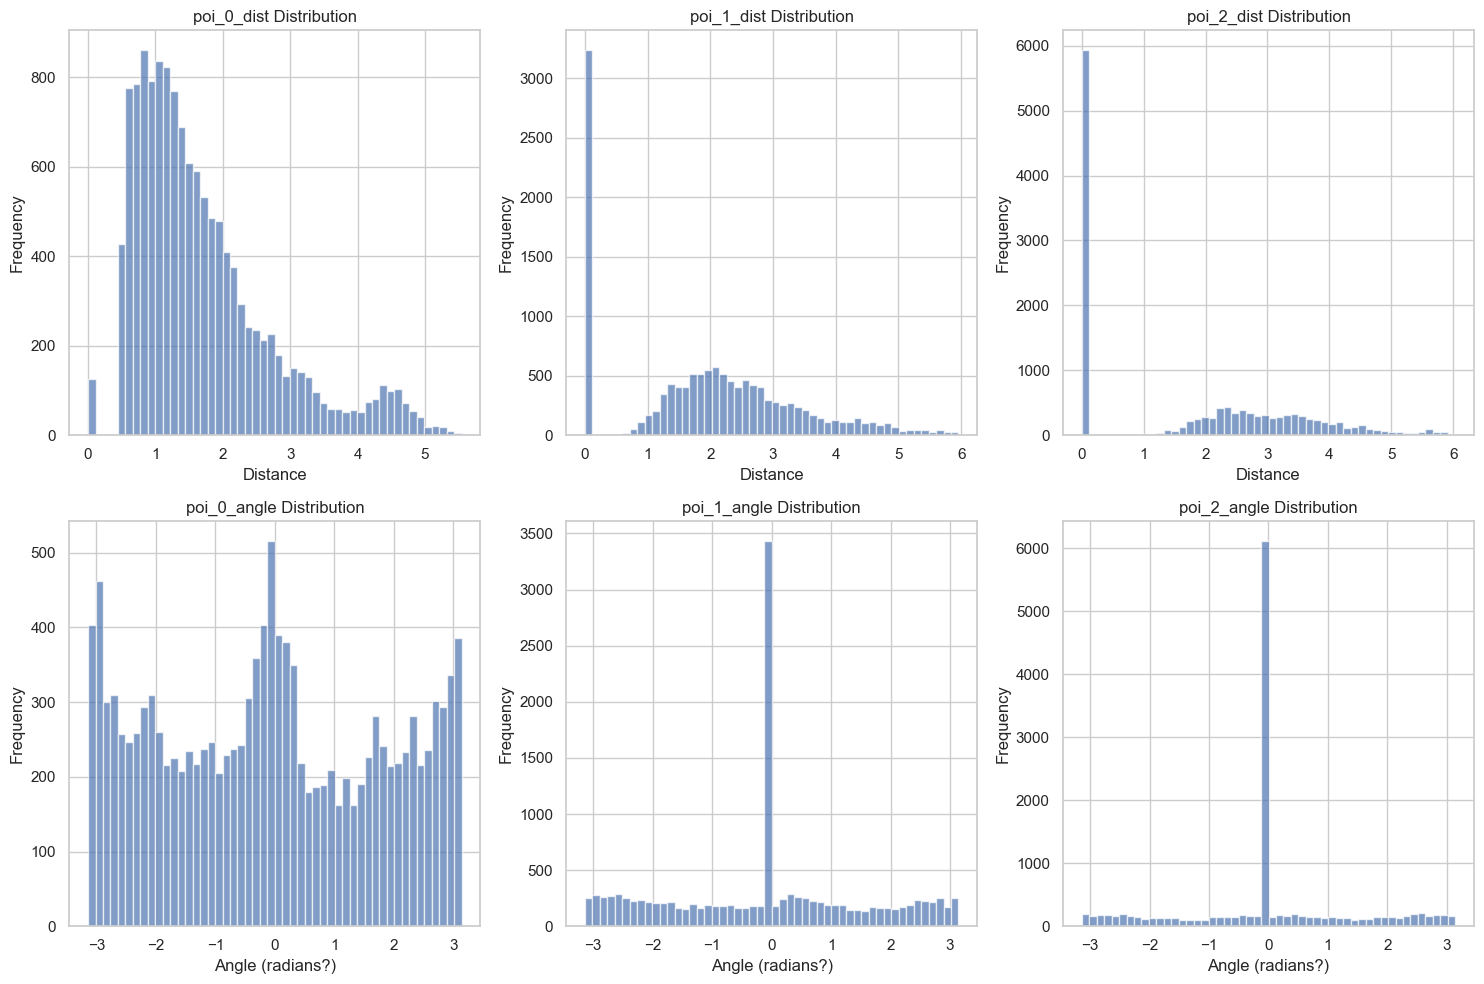


Sample angles: 0    1.185671
1    1.184771
2    1.183313
3    1.182320
4    1.174390
Name: poi_0_angle, dtype: float64
Yaw range: -3.141 to 3.141
Angle range: -3.141 to 3.142


In [123]:
# Analyze POI data validity
import matplotlib.pyplot as plt

poi_cols = [col for col in df_final.columns if 'poi' in col and 'dist' in col]
angle_cols = [col for col in df_final.columns if 'poi' in col and 'angle' in col]

print("POI Distance Statistics:")
print(df_final[poi_cols].describe())

print("\nPOI Angle Statistics:")
print(df_final[angle_cols].describe())

# Check correlation between yaw and angles
yaw_col = 'yaw'
corrs_yaw = df_final[[yaw_col] + angle_cols].corr()
print(f"\nCorrelations between yaw and POI angles:\n{corrs_yaw[yaw_col]}")

# Plot distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, col in enumerate(poi_cols[:3]):
    axes[0, i].hist(df_final[col], bins=50, alpha=0.7)
    axes[0, i].set_title(f'{col} Distribution')
    axes[0, i].set_xlabel('Distance')
    axes[0, i].set_ylabel('Frequency')

for i, col in enumerate(angle_cols[:3]):
    axes[1, i].hist(df_final[col], bins=50, alpha=0.7)
    axes[1, i].set_title(f'{col} Distribution')
    axes[1, i].set_xlabel('Angle (radians?)')
    axes[1, i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Check if angles are in degrees or radians
print(f"\nSample angles: {df_final[angle_cols[0]].head()}")
print(f"Yaw range: {df_final[yaw_col].min():.3f} to {df_final[yaw_col].max():.3f}")
print(f"Angle range: {df_final[angle_cols[0]].min():.3f} to {df_final[angle_cols[0]].max():.3f}")

In [124]:
# Check correlations between POI features and target positions
poi_cols = [col for col in df_final.columns if 'poi' in col]
target_cols = ['x', 'z']

corrs = df_final[poi_cols + target_cols].corr()
print("Correlations between POI features and positions:")
print(corrs.loc[poi_cols, target_cols])

# Also check with velocities and yaw
all_features = ['x', 'z', 'vx', 'vz', 'yaw'] + poi_cols
corrs_full = df_final[all_features].corr()
print("\nFull feature correlations with x and z:")
print(corrs_full.loc[all_features, ['x', 'z']])

# Check if POI features have predictive power
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Simple linear regression for each POI feature to x
for col in poi_cols:
    X_feat = df_final[[col]]
    y_x = df_final['x']
    model_x = LinearRegression().fit(X_feat, y_x)
    r2_x = r2_score(y_x, model_x.predict(X_feat))
    
    y_z = df_final['z']
    model_z = LinearRegression().fit(X_feat, y_z)
    r2_z = r2_score(y_z, model_z.predict(X_feat))
    
    print(f"{col}: R² with x = {r2_x:.4f}, with z = {r2_z:.4f}")

Correlations between POI features and positions:
                    x         z
poi_0_dist   0.034482 -0.005472
poi_0_angle -0.021887 -0.076618
poi_1_dist   0.046146 -0.146342
poi_1_angle  0.113713 -0.041000
poi_2_dist   0.062153 -0.076536
poi_2_angle  0.114299 -0.067094
poi_3_dist  -0.048871  0.009022
poi_3_angle  0.050207 -0.036259
poi_4_dist  -0.127206  0.009964
poi_4_angle  0.003297 -0.050599

Full feature correlations with x and z:
                    x         z
x            1.000000  0.084092
z            0.084092  1.000000
vx           0.018804 -0.035957
vz           0.038105  0.018591
yaw          0.258354  0.026568
poi_0_dist   0.034482 -0.005472
poi_0_angle -0.021887 -0.076618
poi_1_dist   0.046146 -0.146342
poi_1_angle  0.113713 -0.041000
poi_2_dist   0.062153 -0.076536
poi_2_angle  0.114299 -0.067094
poi_3_dist  -0.048871  0.009022
poi_3_angle  0.050207 -0.036259
poi_4_dist  -0.127206  0.009964
poi_4_angle  0.003297 -0.050599
poi_0_dist: R² with x = 0.0012, with z = 0.000

In [125]:
# Train a baseline model without POI features
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Features without POIs: x, z, vx, vz, yaw (5 features)
X_train_no_poi = X_train[:, :, :5]
X_test_no_poi = X_test[:, :, :5]

model_no_poi = Sequential([
    LSTM(64, input_shape=(SEQ_LENGTH, 5)),
    Dense(32, activation='relu'),
    Dense(2)
])

model_no_poi.compile(optimizer='adam', loss='mse')

print("Training model without POI features...")
history_no_poi = model_no_poi.fit(
    X_train_no_poi, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_no_poi, y_test),
    verbose=0
)

preds_no_poi = model_no_poi.predict(X_test_no_poi)

mae_x_no_poi = mean_absolute_error(y_test[:, 0], preds_no_poi[:, 0])
mae_z_no_poi = mean_absolute_error(y_test[:, 1], preds_no_poi[:, 1])
rmse_x_no_poi = np.sqrt(mean_squared_error(y_test[:, 0], preds_no_poi[:, 0]))
rmse_z_no_poi = np.sqrt(mean_squared_error(y_test[:, 1], preds_no_poi[:, 1]))

print(f"Model without POIs - MAE X: {mae_x_no_poi:.4f}, Z: {mae_z_no_poi:.4f}")
print(f"Model without POIs - RMSE X: {rmse_x_no_poi:.4f}, Z: {rmse_z_no_poi:.4f}")

print(f"\nComparison:")
print(f"With POIs - MAE: {mae_overall:.4f}, RMSE: {rmse_overall:.4f}")
print(f"Without POIs - MAE: {(mae_x_no_poi + mae_z_no_poi)/2:.4f}, RMSE: {(rmse_x_no_poi + rmse_z_no_poi)/2:.4f}")

# Check if POIs improve performance
if mae_overall < (mae_x_no_poi + mae_z_no_poi)/2:
    print("POI features improve model performance.")
else:
    print("POI features do not improve (or worsen) model performance.")

Training model without POI features...


c:\Users\JetPa\anaconda3\envs\mnist_tf2\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Model without POIs - MAE X: 0.0124, Z: 0.0166
Model without POIs - RMSE X: 0.0159, Z: 0.0206

Comparison:
With POIs - MAE: 0.0410, RMSE: 0.0515
Without POIs - MAE: 0.0145, RMSE: 0.0183
POI features do not improve (or worsen) model performance.
